⏳ Loading target dataset: '1) iris.csv'...

⚙️ Iterating KNN variations across different values of K...
  K-Value   |   Accuracy Score   |  Performance Notes
  K = 1       |   93.33%        |  Highly sensitive boundary
  K = 3       |   91.11%        |  Generalized voting block
  K = 5       |   91.11%        |  Generalized voting block
  K = 7       |   93.33%        |  Optimal neighborhood
  K = 9       |   95.56%        |  Optimal neighborhood
  K = 15      |   93.33%        |  Generalized voting block

🎯 Generating Full Metrics Breakdown for Optimal Setup (K=5)...

             KNN COMPREHENSIVE SCORECARD (K=5)
Overall Holdout Test Accuracy: 91.11%
-------------------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro av

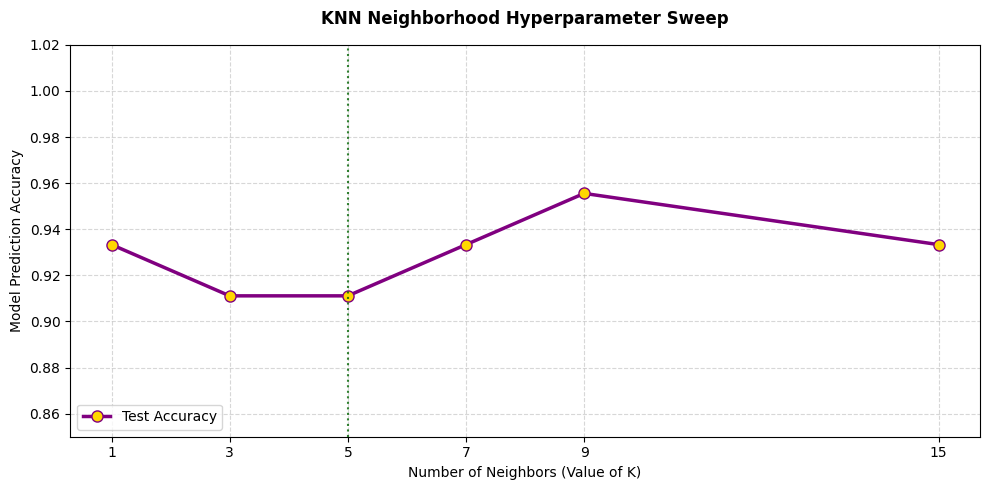


✔️ Execution successful! Check your active graphics engine panel.


In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =====================================================================
# 1. DATA INGESTION & TARGET SEPARATION
# =====================================================================
filename = '1) iris.csv'

if not os.path.exists(filename):
    raise FileNotFoundError(
        f"Missing dataset file '{filename}' in directory '{os.getcwd()}'. "
        f"Please verify it is uploaded to your environment."
    )

print(f"⏳ Loading target dataset: '{filename}'...")
df_iris = pd.read_csv(filename)

# Isolate features (X) and target class labels (y)
X = df_iris.drop(columns=['species'])
y = df_iris['species']

# Stratify to ensure all flower types are evenly distributed in train and test splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =====================================================================
# 2. MANDATORY GEOMETRIC FEATURE SCALING
# =====================================================================
# Crucial for KNN so feature scales don't warp distance calculations!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================================
# 3. K-VALUE PARADIGM SWEEP
# =====================================================================
k_values = [1, 3, 5, 7, 9, 15]
accuracy_scores = []

print("\n⚙️ Iterating KNN variations across different values of K...")
print("="*65)
print("  K-Value   |   Accuracy Score   |  Performance Notes")
print("="*65)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    accuracy_scores.append(acc)

    notes = "Highly sensitive boundary" if k == 1 else "Optimal neighborhood" if acc == max(accuracy_scores) else "Generalized voting block"
    print(f"  K = {k:<7} |   {acc*100:.2f}%{' '*7} |  {notes}")

print("="*65)

# =====================================================================
# 4. DEEP-DIVE EVALUATION FOR THE OPTIMAL MODEL (e.g., K = 5)
# =====================================================================
optimal_k = 5
print(f"\n🎯 Generating Full Metrics Breakdown for Optimal Setup (K={optimal_k})...")

optimal_knn = KNeighborsClassifier(n_neighbors=optimal_k)
optimal_knn.fit(X_train_scaled, y_train)
y_pred_optimal = optimal_knn.predict(X_test_scaled)

print("\n" + "="*55)
print(f"             KNN COMPREHENSIVE SCORECARD (K={optimal_k})")
print("="*55)
print(f"Overall Holdout Test Accuracy: {accuracy_score(y_test, y_pred_optimal) * 100:.2f}%")
print("-"*55)
print(classification_report(y_test, y_pred_optimal))
print("-"*55)
print("Confusion Matrix Layout:")
print(confusion_matrix(y_test, y_pred_optimal))
print("="*55)

# =====================================================================
# 5. GENERATING VISUALIZATION ERROR MAPS
# =====================================================================
print("\n📊 Rendering K-Value Optimization Profile Plot...")

plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracy_scores, color='purple', linestyle='-', marker='o',
         markerfacecolor='gold', markersize=8, linewidth=2.5, label='Test Accuracy')

plt.title('KNN Neighborhood Hyperparameter Sweep', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Number of Neighbors (Value of K)', fontsize=10)
plt.ylabel('Model Prediction Accuracy', fontsize=10)
plt.xticks(k_values)
plt.ylim([0.85, 1.02])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="lower left")

# Highlight the peak performance sweet spot
plt.axvline(x=optimal_k, color='darkgreen', linestyle=':', alpha=0.8, label=f'Chosen Optimal K ({optimal_k})')

plt.tight_layout()
plt.show()

print("\n✔️ Execution successful! Check your active graphics engine panel.")